## Simple convolution neural network
1. Import PyToch lib and functions
2. Define our Transformer
3. Load the dataset
4. Inspect and visualization our image dataset
5. Create our data loader for load batches of images
6. Building our Model
7. Training our Model
8. Analyizing its accuracy
9. Saving our Model
10. Plotting our training logs

### 1. Importing libraries

In [1]:
import torch
# use for dataset and useful image transformations
import torchvision
import torchvision.transforms as transforms
# import optimiztion lib
# nn is basic building block for our network graphs
import torch.optim as optim
import torch.nn as nn

print(torch.cuda.is_available())

False


### 2. Transformer

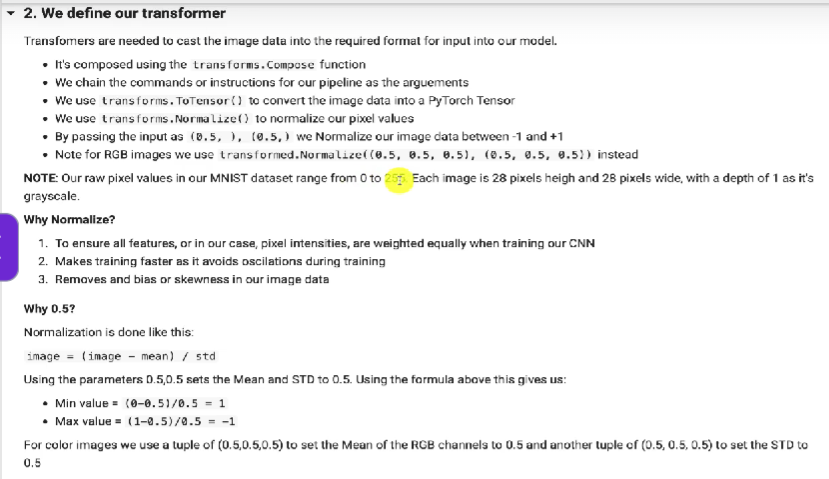

In [2]:
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,),(0.5,))])

### 3. Loading dataset

In [3]:
trainset = torchvision.datasets.MNIST("mnist",train=True,download=True,transform=transform)

In [4]:
testset = torchvision.datasets.MNIST("mnist",train=False,download=True,transform=transform)

In [5]:
print(trainset.data.shape)
print(testset.data.shape)

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


Visulize the dataset

In [6]:
trainset.data[0]

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

In [9]:
from matplotlib import pyplot as plt
import cv2
def imgshow(title="",image=None,size=6):
    w,h = image.shape[0],image.shape[1]
    aspectRatio = w/h
    plt.figure(figsize=(size*aspectRatio,size))
    plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

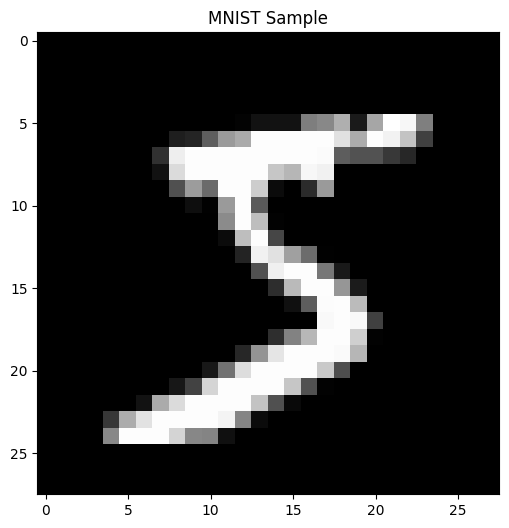

In [10]:
image = trainset.data[0].numpy()
imgshow("MNIST Sample",image=image)

### 4. Data Loaders

In [11]:
trainloader = torch.utils.data.DataLoader(trainset,batch_size=128,shuffle=True,num_workers=0)
testloader = torch.utils.data.DataLoader(testset,batch_size=128,shuffle=False,num_workers=0)

In [12]:
# we use the python function iter to return an iterator for our train_loader object
dataiter = iter(trainloader)

images, lables = dataiter._next_data()
print(images.shape)
print(lables.shape)


torch.Size([128, 1, 28, 28])
torch.Size([128])


### 5. Building the nodel
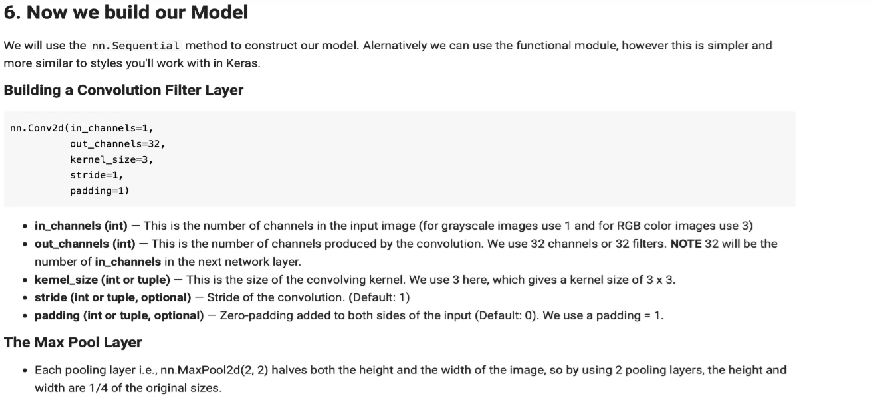
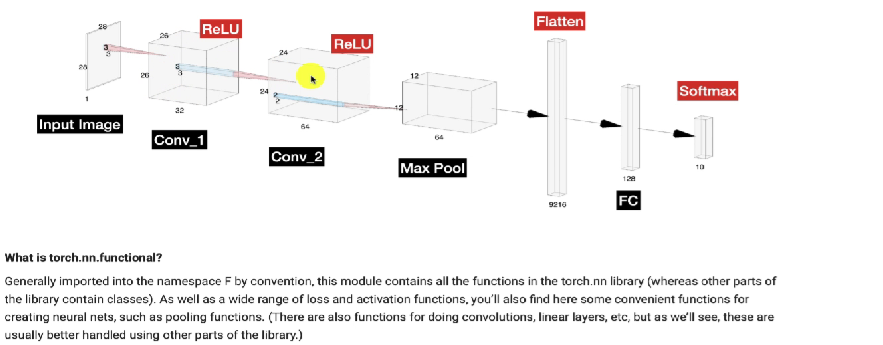

In [13]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1,
                               out_channels=32,
                               kernel_size=3)
        self.conv2 = nn.Conv2d(
            in_channels=1,out_channels=64,kernel_size=3
        )
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)
        self.fc1 = nn.Linear(64*12*12,128)
        self.fc2 = nn.Linear(128,10)
        
    def forward(self,x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.pool(x)
        x = x.view(-1,64*64*12)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

net = Net()


In [14]:
net

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

### 6. Define the optimizer and loss function
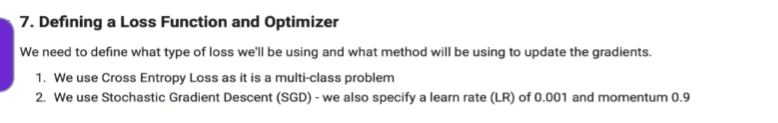

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(),lr=0.001,momentum=0.9)

### 7. Training the model
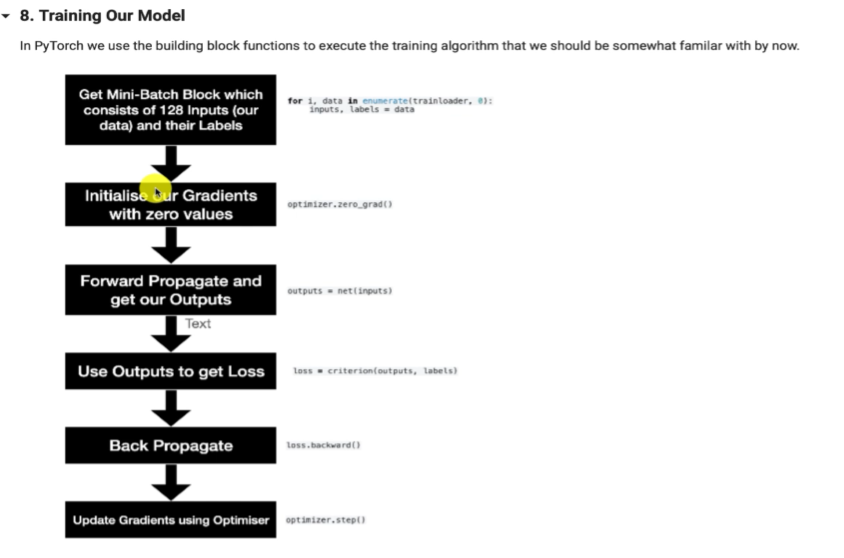

In [18]:
epochs =10

## creating list to store the logs
epoch_log = []
loss_log = []
accuravcy_log = []

# Iterate for a specified number of epochs
for epoch in range(epochs):
    running_loss = 0.0

    for i, data in enumerate(trainloader,0):
        input, lables = data

        optimizer.zero_grad()

        outputs = net(input)
        loss = criterion(outputs,lables)

        loss.backward()
        optimizer.step()

        running_loss = running_loss + loss.item()
        if i%50 ==49:
            correct = 0
            total = 0

            with torch.no_grad():
                for data in testloader:
                    images, labels = data
                    outputs = net(images)

                    _, predicted = torch.max(outputs.data, dim=1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().items()
            
            accuracy = 100 * correct / total
            epoch_num = epoch+1
            actual_loss = running_loss /50
            print(f" Epoch {epoch_num} mini batch completed {(i+1)} loss {actual_loss} test_accuracy {accuracy}")
            running_loss =0.0

        epoch_log.append(epoch_num)
        loss_log.append(actual_loss)
        accuravcy_log.append(accuracy)

    print("training finished")


RuntimeError: Given groups=1, weight of size [64, 1, 3, 3], expected input[128, 32, 26, 26] to have 1 channels, but got 32 channels instead

In [ ]:
path = "torch_model.pth"
torch.save(net.state_dict(),path)

net = Net()
net.load_state_dict(torch.load(path))